In [1]:
# DAY 33 - DETECTING UNUSUAL CUSTOMER BEHAVIOR

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

print("Day 33 libraries imported successfully!")

Day 33 libraries imported successfully!


In [2]:
# Load the cleaned sales dataset

df = pd.read_csv("../cleaned_dataset.csv")

print("Sales dataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nImportant columns:")
print([
    "customer_name",
    "sales",
    "quantity",
    "discount",
    "profit",
    "shipping_days"
])

df.head()

Sales dataset loaded successfully!
Dataset shape: (51290, 23)

Important columns:
['customer_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_days']


,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,shipping_days,profit_margin
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,5,26.014706
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,7,30.030000
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,4,44.909091
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,4,-57.900000
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,7,33.131579


In [3]:
# Create customer-level behavior data

customer_data = df.groupby("customer_name").agg(
    total_sales=("sales", "sum"),
    total_quantity=("quantity", "sum"),
    total_profit=("profit", "sum"),
    average_discount=("discount", "mean"),
    average_shipping_days=("shipping_days", "mean"),
    number_of_orders=("order_id", "count")
).reset_index()

print("Customer behavior data created successfully!")
print("Number of customers:", customer_data.shape[0])

print("\nCustomer behavior columns:")
print(customer_data.columns.tolist())

display(customer_data.head())

Customer behavior data created successfully!
Number of customers: 795

Customer behavior columns:
['customer_name', 'total_sales', 'total_quantity', 'total_profit', 'average_discount', 'average_shipping_days', 'number_of_orders']


,customer_name,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders
0,Aaron Bergman,24646.0,301,4683.20800,0.110112,3.707865,89
1,Aaron Hawkins,20759.0,231,2450.92904,0.160929,3.464286,56
2,Aaron Smayling,14207.0,211,369.16180,0.167667,4.433333,60
3,Adam Bellavance,20189.0,262,4979.97690,0.131765,3.514706,68
4,Adam Hart,21720.0,293,1902.03342,0.093238,3.654762,84


In [4]:
# Select features for anomaly detection

feature_columns = [
    "total_sales",
    "total_quantity",
    "total_profit",
    "average_discount",
    "average_shipping_days",
    "number_of_orders"
]

X = customer_data[feature_columns]

print("Features selected successfully!")

print("\nFeatures used for anomaly detection:")
for feature in feature_columns:
    print("-", feature)

print("\nFeature data shape:", X.shape)

display(X.head())

Features selected successfully!

Features used for anomaly detection:
- total_sales
- total_quantity
- total_profit
- average_discount
- average_shipping_days
- number_of_orders

Feature data shape: (795, 6)


,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders
0,24646.0,301,4683.20800,0.110112,3.707865,89
1,20759.0,231,2450.92904,0.160929,3.464286,56
2,14207.0,211,369.16180,0.167667,4.433333,60
3,20189.0,262,4979.97690,0.131765,3.514706,68
4,21720.0,293,1902.03342,0.093238,3.654762,84


In [5]:
# Standardize customer behavior features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Customer behavior features standardized successfully!")

print("Scaled data shape:", X_scaled.shape)

print("\nFirst 5 scaled rows:")
print(X_scaled[:5])

Customer behavior features standardized successfully!
Scaled data shape: (795, 6)

First 5 scaled rows:
[[ 1.67923479  1.51782672  1.83675336 -0.73064577 -0.72146871  1.8239146 ]
 [ 0.93267132  0.13273486  0.3906802   0.39657357 -1.38947874 -0.63436434]
 [-0.32575005 -0.26300567 -0.95789127  0.54603987  1.26810801 -0.33639113]
 [ 0.82319327  0.74613269  2.02900063 -0.2503474  -1.2512028   0.25955528]
 [ 1.11724747  1.35953051  0.03510492 -1.10495539 -0.86710297  1.45144809]]


In [6]:
# Apply Isolation Forest for anomaly detection

model = IsolationForest(
    contamination=0.05,
    random_state=42
)

customer_data["anomaly"] = model.fit_predict(X_scaled)

print("Isolation Forest applied successfully!")

print("\nAnomaly values:")
print(customer_data["anomaly"].value_counts())

Isolation Forest applied successfully!

Anomaly values:
anomaly
 1    755
-1     40
Name: count, dtype: int64


In [7]:
# Create readable anomaly labels

customer_data["behavior_status"] = np.where(
    customer_data["anomaly"] == -1,
    "Anomalous",
    "Normal"
)

print("Behavior labels created successfully!")

print("\nNormal vs Anomalous Customers:")
print(customer_data["behavior_status"].value_counts())

display(
    customer_data[
        ["customer_name", "behavior_status"]
    ].head(10)
)

Behavior labels created successfully!

Normal vs Anomalous Customers:
behavior_status
Normal       755
Anomalous     40
Name: count, dtype: int64


,customer_name,behavior_status
0,Aaron Bergman,Normal
1,Aaron Hawkins,Normal
2,Aaron Smayling,Normal
3,Adam Bellavance,Normal
4,Adam Hart,Normal
5,Adam Shillingsburg,Normal
6,Adrian Barton,Normal
7,Adrian Hane,Normal
8,Adrian Shami,Normal
9,Aimee Bixby,Normal


In [8]:
# View anomalous customers

anomalous_customers = customer_data[
    customer_data["behavior_status"] == "Anomalous"
].copy()

print("Number of anomalous customers:", len(anomalous_customers))

print("\nAnomalous customer behavior:")
display(
    anomalous_customers[
        [
            "customer_name",
            "total_sales",
            "total_quantity",
            "total_profit",
            "average_discount",
            "average_shipping_days",
            "number_of_orders",
            "behavior_status"
        ]
    ].sort_values(
        "total_sales",
        ascending=False
    )
)

Number of anomalous customers: 40

Anomalous customer behavior:


,customer_name,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders,behavior_status
758,Tom Ashbrook,40489.0,284,6311.97910,0.090125,4.100000,80,Anomalous
731,Tamara Chand,37453.0,271,8672.89890,0.184682,3.545455,88,Anomalous
313,Greg Tran,35552.0,310,5214.13118,0.141448,4.528736,87,Anomalous
157,Christopher Conant,35187.0,287,5603.33370,0.129041,3.794521,73,Anomalous
687,Sean Miller,35170.0,169,-409.70634,0.190240,4.440000,50,Anomalous
73,Bart Watters,32315.0,338,3595.88590,0.096667,3.958333,96,Anomalous
558,Natalie Fritzler,31778.0,325,1542.82110,0.179474,3.989474,95,Anomalous
335,Hunter Lopez,30246.0,207,7816.56778,0.117774,4.905660,53,Anomalous
673,Sanjit Engle,30143.0,299,6015.78392,0.062244,4.390244,82,Anomalous
552,Muhammed Yedwab,29644.0,351,2642.65408,0.154833,3.916667,108,Anomalous


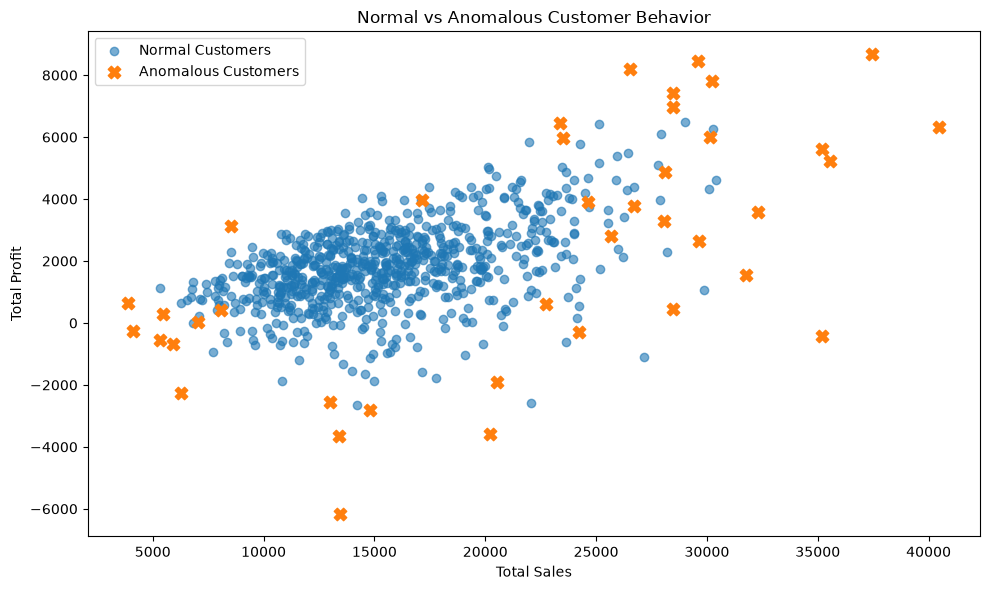

Anomaly visualization created successfully!


In [9]:
# Visualize normal vs anomalous customers

plt.figure(figsize=(10, 6))

normal_customers = customer_data[
    customer_data["behavior_status"] == "Normal"
]

plt.scatter(
    normal_customers["total_sales"],
    normal_customers["total_profit"],
    label="Normal Customers",
    alpha=0.6
)

plt.scatter(
    anomalous_customers["total_sales"],
    anomalous_customers["total_profit"],
    label="Anomalous Customers",
    s=80,
    marker="X"
)

plt.xlabel("Total Sales")
plt.ylabel("Total Profit")
plt.title("Normal vs Anomalous Customer Behavior")
plt.legend()

plt.tight_layout()

plt.savefig(
    "customer_anomalies.png",
    dpi=300
)

plt.show()

print("Anomaly visualization created successfully!")

In [10]:
# Compare normal and anomalous customer behavior

behavior_comparison = customer_data.groupby(
    "behavior_status"
)[feature_columns].mean().round(2)

print("Normal vs anomalous behavior comparison:")

display(behavior_comparison)

Normal vs anomalous behavior comparison:


,total_sales,total_quantity,total_profit,average_discount,average_shipping_days,number_of_orders
behavior_status,,,,,,
Anomalous,21846.32,242.62,2349.88,0.16,4.08,67.78
Normal,15588.15,223.32,1821.24,0.14,3.96,64.34


In [11]:
# Create business risk analysis

risk_analysis = """
# Business Risk Analysis - Customer Anomaly Detection

## Objective

The anomaly detection model identifies customers whose
behavior is significantly different from the majority of
customers.

## Possible Business Risks

### 1. Unusual Spending
Very high or very low spending may require additional
business analysis.

### 2. Unusual Order Volume
A customer with an unusually high number of orders may
represent an important business opportunity or unusual
activity.

### 3. Unusual Discounts
Customers receiving unusually high discounts may affect
profitability.

### 4. Unusual Profit Patterns
Extremely high or low profit values may indicate unusual
purchasing patterns or pricing situations.

### 5. Unusual Shipping Behavior
Significantly different shipping times may indicate
operational or delivery-related issues.

## Business Actions

- Review anomalous customer records
- Investigate unusual purchasing patterns
- Monitor high-risk operational cases
- Check discount and profitability patterns
- Use anomalies as signals for further investigation

## Important Note

An anomaly does not automatically mean fraud or suspicious
activity. It only indicates that the customer's behavior is
different from the normal pattern.
"""

with open(
    "business_risk_analysis.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(risk_analysis)

print("Business risk analysis created successfully!")

Business risk analysis created successfully!


In [12]:
# Save anomaly detection results

customer_data.to_csv(
    "customer_anomaly_results.csv",
    index=False
)

anomalous_customers.to_csv(
    "anomalous_customers.csv",
    index=False
)

behavior_comparison.to_csv(
    "behavior_comparison.csv"
)

print("Anomaly detection results saved successfully!")

print("\nFiles created:")
print("- customer_anomaly_results.csv")
print("- anomalous_customers.csv")
print("- behavior_comparison.csv")
print("- customer_anomalies.png")
print("- business_risk_analysis.md")

Anomaly detection results saved successfully!

Files created:
- customer_anomaly_results.csv
- anomalous_customers.csv
- behavior_comparison.csv
- customer_anomalies.png
- business_risk_analysis.md


In [13]:
# Check Day 33 output files

import os

files_to_check = [
    "day33.ipynb",
    "customer_anomaly_results.csv",
    "anomalous_customers.csv",
    "behavior_comparison.csv",
    "customer_anomalies.png",
    "business_risk_analysis.md",
    "README.md"
]

print("Day 33 file check:\n")

for file in files_to_check:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file, "- NOT FOUND")

print("\nDay 33 file check completed!")

Day 33 file check:

✓ day33.ipynb
✓ customer_anomaly_results.csv
✓ anomalous_customers.csv
✓ behavior_comparison.csv
✓ customer_anomalies.png
✓ business_risk_analysis.md
✓ README.md

Day 33 file check completed!
